In [ ]:
%pip install pandas
%pip install duckdb
%pip install matplotlib
%pip install seaborn

In [2]:
import pandas as pd

pd.set_option("display.max_columns", None)  # show all cols
pd.set_option("display.max_colwidth", None)  # show full width of showing cols
pd.set_option(
    "display.expand_frame_repr", False
)  # print cols side by side as it's supposed to be

In [3]:
import duckdb

ODIS_DUCKDB_FILE = "odis.duckdb"
PCC_DUCKDB_FILE = "dev.duckdb"

con = duckdb.connect(database=PCC_DUCKDB_FILE, read_only=True)
con.sql(f"ATTACH '{ODIS_DUCKDB_FILE}' AS odis;")

In [11]:
query_jo = '''
SELECT
	cod_commune, lib_commune, lib_risque_jo, dat_pub_jo
FROM dev.main.catnat_gaspar

'''

new_data = con.sql(query_jo)
df = new_data.df()
df.head()

,cod_commune,lib_commune,lib_risque_jo,dat_pub_jo
0,06120,Saint-Étienne-de-Tinée,Glissement de Terrain,1987-05-24
1,2B050,Calvi,Inondations et/ou Coulées de Boue,1987-07-10
2,30006,Aimargues,Inondations et/ou Coulées de Boue,1987-07-10
3,30020,Aubord,Inondations et/ou Coulées de Boue,1987-07-10
4,30033,Beauvoisin,Inondations et/ou Coulées de Boue,1987-07-10


In [10]:
df.head()

,cod_commune,lib_commune,lib_risque_jo,dat_pub_jo
0,06120,Saint-Étienne-de-Tinée,Glissement de Terrain,1987-05-24
1,2B050,Calvi,Inondations et/ou Coulées de Boue,1987-07-10
2,30006,Aimargues,Inondations et/ou Coulées de Boue,1987-07-10
3,30020,Aubord,Inondations et/ou Coulées de Boue,1987-07-10
4,30033,Beauvoisin,Inondations et/ou Coulées de Boue,1987-07-10


In [15]:
df['année_jo'] = df['dat_pub_jo'].str[:4].astype(int)
df['Département'] = df['cod_commune'].str[:2]
df.head()

,cod_commune,lib_commune,lib_risque_jo,dat_pub_jo,année_jo,dep,Département
0,06120,Saint-Étienne-de-Tinée,Glissement de Terrain,1987-05-24,1987,06,06
1,2B050,Calvi,Inondations et/ou Coulées de Boue,1987-07-10,1987,2B,2B
2,30006,Aimargues,Inondations et/ou Coulées de Boue,1987-07-10,1987,30,30
3,30020,Aubord,Inondations et/ou Coulées de Boue,1987-07-10,1987,30,30
4,30033,Beauvoisin,Inondations et/ou Coulées de Boue,1987-07-10,1987,30,30


In [16]:
df_grouped_jo = df.groupby(["année_jo","Département"])["Département"].count().reset_index(name='count')
df_grouped_jo.head()

,année_jo,Département,count
0,1982,01,2
1,1982,03,634
2,1982,06,168
3,1982,07,706
4,1982,09,654


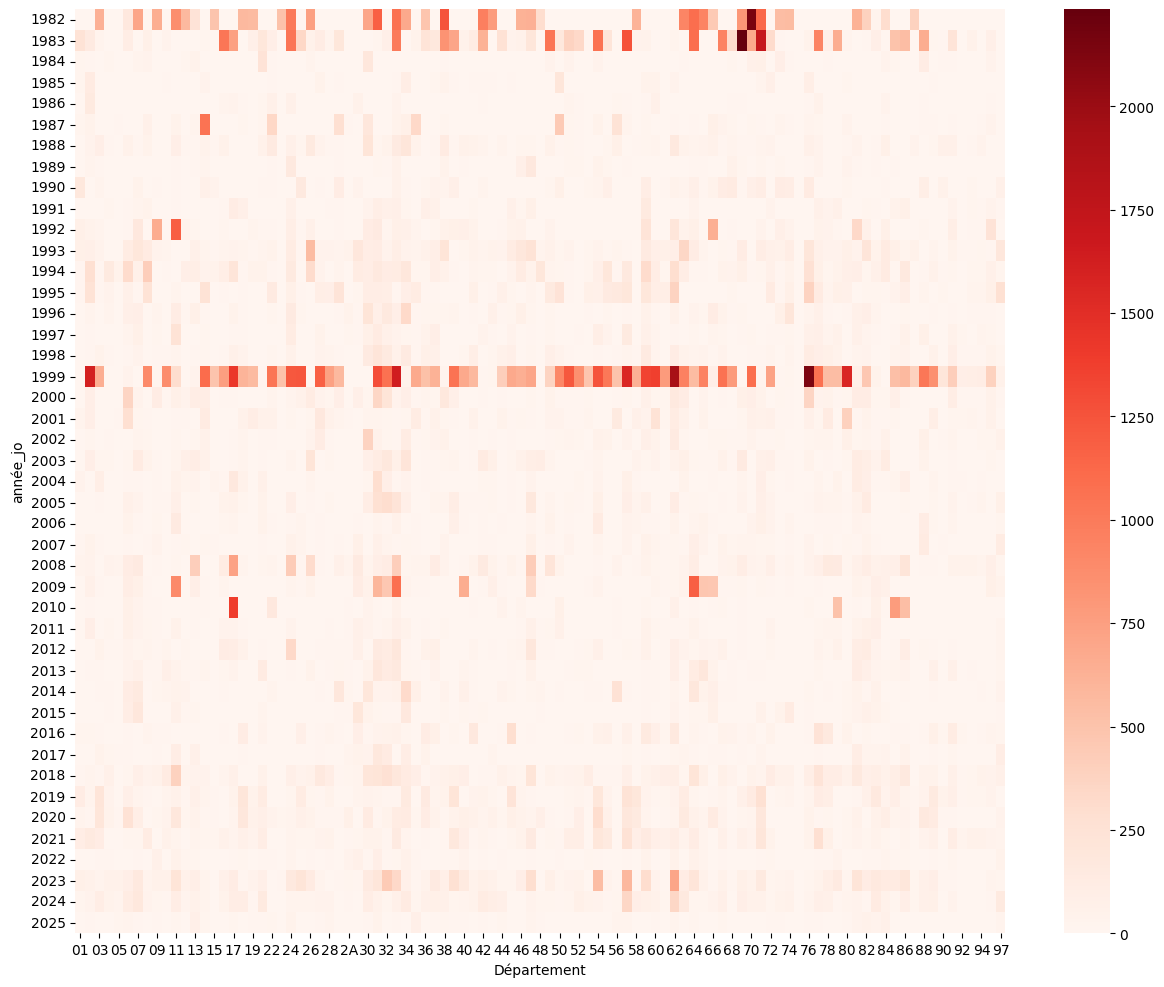

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

pivot_jo = df_grouped_jo.pivot_table(
    index="année_jo",
    columns="Département",
    values="count"
).fillna(0)

plt.figure(figsize=(15, 12))
sns.heatmap(pivot_jo, cmap="Reds")
plt.title("")
plt.show()


#### Année 1999 particulièrement marquée par les catnat notamment suite aux tempêtes dévastatrices qu'a connu la France au 25 et 26 Décembre. 

In [27]:
df_grouped_jo.sort_values(by = "count", ascending = False).head(10)

,année_jo,Département,count
100,1983,69,2235
35,1982,70,2156
1384,1999,76,2131
1370,1999,62,1933
102,1983,71,1712
1342,1999,33,1640
1312,1999,02,1612
1388,1999,80,1566
1365,1999,57,1555
1327,1999,17,1431


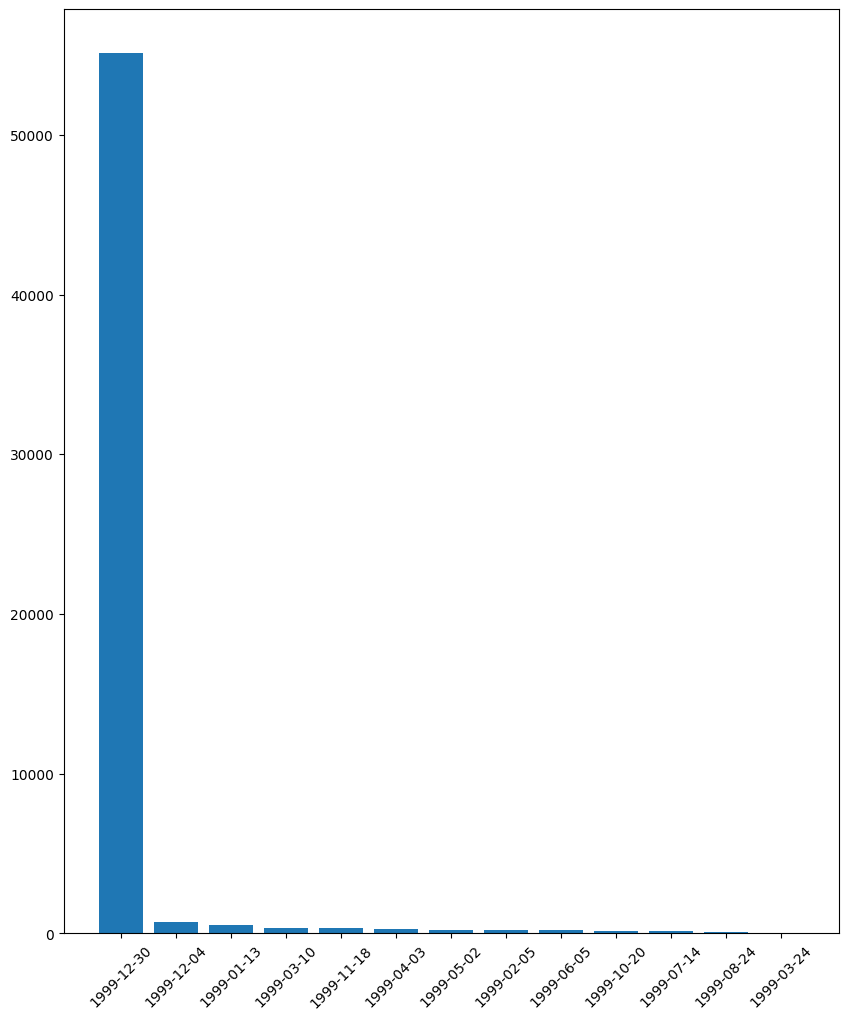

In [32]:
année_99_jo= df[df["année_jo"] == 1999]

a = année_99_jo["dat_pub_jo"].value_counts().reset_index(name="total")

plt.figure(figsize=(10,12))
plt.bar(a["dat_pub_jo"], a["total"])
plt.xticks(rotation=45)
plt.show()

#### Ce graphique nous confirme bien que les deux tempêtes du 25 et 26 Décembre 1999 qui ont ravagées la France représentent la majorité des Castatrophes Naturelles de 1999 enregistrées en arrêté au 29/12/1999 et au JO au 30/12/1999